# Notebook 02.1 — Limpeza e Preparação Topológica da Malha Viária

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — Pipeline AE2SFCA  
**Autor:** Felipe Ramos Dantas  
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI  
**Repositório:** https://github.com/felipedantas-pi/mapeprof-accessibility-ubs  
**Última atualização:** 2026

---

## Objetivo
Processar os segmentos viários brutos extraídos no **Notebook 01.2**. Este roteiro foca em:
1. **Filtro Semântico:** Remoção de infraestrutura não-terrestre (ferrovias e vias navegáveis).
2. **Correção Topológica:** Criação de nós de interseção reais (*connector splitting*) utilizando a biblioteca `city2graph`.
3. **Engenharia de Atributos:** Extração de metadados complexos (JSON) em valores numéricos (Velocidade Máxima, Comprimento, Linearidade).

**Saída:** `zonaUrbanaReal_5km_road_cleaned.parquet` (Dado perfeitamente íntegro, pronto para a imputação de Inteligência Artificial no NB 02.2).

---

In [2]:
import warnings
from pathlib import Path
import ast
import json
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import city2graph as c2g
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Configurações de Qualidade Visual (Padrão Dissertação) ──────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.family': 'serif',
    'font.size': 10, 'axes.facecolor': '#F8F8F8', 'axes.grid': True,
    'grid.alpha': 0.4, 'grid.linestyle': '--',
})
warnings.filterwarnings("ignore")

# ── Definição de Caminhos e SRC ──────────────────────────────────────────────
RAW_PATH = Path('../dados/brutos')
PROCESSED_PATH = Path('../dados/processados')
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
FIGURAS_PATH = Path('../outputs/figuras/nb021')
FIGURAS_PATH.mkdir(parents=True, exist_ok=True)

CRS_GEOGRAFICO = 'EPSG:4674'   # SIRGAS 2000 (latitude/longitude)
CRS_METRICO = 'EPSG:31983' # SIRGAS 2000 / UTM 23S (Obrigatório para cálculo de distâncias em metros)

print(f"✅ Setup concluído. city2graph version: {c2g.__version__ if hasattr(c2g, '__version__') else 'development'}")

✅ Setup concluído. city2graph version: 0.3.1


In [14]:
# Carregamos exclusivamente os dados necessários para esta etapa topológica
print("🔄 Carregando dados brutos da área de estudo (5 km)...")
segments_gdf = gpd.read_file(RAW_PATH / 'overture/zonaUrbanaReal_5km_segmentos.geojson')
connectors_gdf = gpd.read_file(RAW_PATH / 'overture/zonaUrbanaReal_5km_conectores.geojson')

# Opcional: Carregar limite urbano para os mapas na etapa final
zu_gdf = gpd.read_parquet(RAW_PATH / 'ibge/teresina_zonaUrbana_utm.parquet')

# Garantia de reprojeção métrica
segments_gdf.to_crs(CRS_METRICO, inplace=True)
connectors_gdf.to_crs(CRS_METRICO, inplace=True)
zu_gdf.to_crs(CRS_METRICO, inplace=True)

print(f"✅ Dados em memória: {len(segments_gdf):,} segmentos e {len(connectors_gdf):,} conectores.")

🔄 Carregando dados brutos da área de estudo (5 km)...
✅ Dados em memória: 46,477 segmentos e 34,742 conectores.


In [16]:
# ── 1. Filtro Semântico (Remoção de Ferrovias/Rios) ──────────────────────────
# Mantemos apenas infraestrutura terrestre ('road')
total_bruto = len(segments_gdf)
road_gdf = segments_gdf[segments_gdf['subtype'] == 'road'].copy()
removidos = total_bruto - len(road_gdf)

print(f"🚜 Filtro aplicado. Mantidos: {len(road_gdf):,} segmentos ('road').")
print(f"   Descartados: {removidos} segmentos ('rail'/'water').")

🚜 Filtro aplicado. Mantidos: 46,439 segmentos ('road').
   Descartados: 38 segmentos ('rail'/'water').


In [17]:
# ── 2. Correção Topológica (City2Graph) ──────────────────────────────────────
# Esta é a etapa mais crítica para o cálculo de isócronas no futuro.
# Corta ruas nas interseções (split) e junta pontas soltas (snap).

print("⚙️ Iniciando processamento topológico (Isso pode levar alguns segundos)...")
road_process = c2g.process_overture_segments(
    segments_gdf=road_gdf,
    get_barriers=False,       # Desativado pois não focamos no morphological_graph() aqui
    connectors_gdf=connectors_gdf,
    threshold=3.0             # Tolerância de snap em metros
)

print(f"✅ Topologia corrigida! O grafo base agora possui {len(road_process):,} arestas viárias.")

⚙️ Iniciando processamento topológico (Isso pode levar alguns segundos)...
✅ Topologia corrigida! O grafo base agora possui 52,431 arestas viárias.


In [18]:
# ── 3. Engenharia de Atributos ───────────────────────────────────────────────

def extrair_velocidade_maxima(valor):
    """Extrai o valor numérico da velocidade do JSON aninhado da Overture."""
    if pd.isna(valor) or valor is None:
        return None
    obj = valor
    if isinstance(obj, str):
        s = obj.strip()
        if not s or s.lower() in ('none', 'nan', 'null'):
            return None
        for parser in (ast.literal_eval, json.loads):
            try:
                obj = parser(s)
                break
            except:
                continue
    
    velocidades = []
    if isinstance(obj, list):
        for item in obj:
            if isinstance(item, dict) and isinstance(item.get('max_speed'), dict):
                val = item['max_speed'].get('value')
                if val is not None:
                    velocidades.append(float(val))
    elif isinstance(obj, dict) and isinstance(obj.get('max_speed'), dict):
        val = obj['max_speed'].get('value')
        if val is not None:
            velocidades.append(float(val))
            
    return max(velocidades) if velocidades else None

def calcular_linearidade(geom):
    """Razão entre distância reta (ponta a ponta) e o comprimento total da curva. Usado pela IA."""
    try:
        distancia_euclidiana = Point(geom.coords[0]).distance(Point(geom.coords[-1]))
        return distancia_euclidiana / geom.length if geom.length > 0 else 0.0
    except:
        return 0.0

print("🔬 Extraindo métricas avançadas...")
road_process['velocidade_max'] = road_process['speed_limits'].apply(extrair_velocidade_maxima)
road_process['linearity'] = road_process.geometry.apply(calcular_linearidade)

# Salva a classificação original da via. Se for 'unknown', a IA vai substituir depois.
road_process['classe_original'] = road_process['class'].copy()

print("✅ Atributos extraídos. Resumo da Linearidade e Velocidade (km/h):")
print(road_process[['linearity', 'velocidade_max']].describe().round(2))

🔬 Extraindo métricas avançadas...
✅ Atributos extraídos. Resumo da Linearidade e Velocidade (km/h):
       linearity  velocidade_max
count   52431.00         6878.00
mean        0.98           54.25
std         0.08           11.79
min         0.00           10.00
25%         1.00           50.00
50%         1.00           60.00
75%         1.00           60.00
max         1.00          100.00


In [19]:
# ── 4. Exportação do Dataset Preparado ───────────────────────────────────────
# O arquivo salvo aqui é a ÚNICA fonte da verdade que alimentará o Notebook 02.2 (GNN)
caminho_saida = PROCESSED_PATH / "zonaUrbanaReal_5km_road_cleaned.parquet"
caminho_saida = PROCESSED_PATH / "zonaUrbanaReal_5km_road_cleaned.geojson"
road_process.to_parquet(caminho_saida)
road_process.to_file(caminho_saida, driver='GeoJSON')
print(f"💾 Base viária limpa salva com sucesso em: {caminho_saida}")

💾 Base viária limpa salva com sucesso em: ..\dados\processados\zonaUrbanaReal_5km_road_cleaned.geojson


---
## Análise Exploratória Cartográfica (Para a Dissertação)
As células abaixo não afetam os dados. Servem exclusivamente para gerar as estatísticas e as **Figuras 4.1 e 4.x** do relatório metodológico.

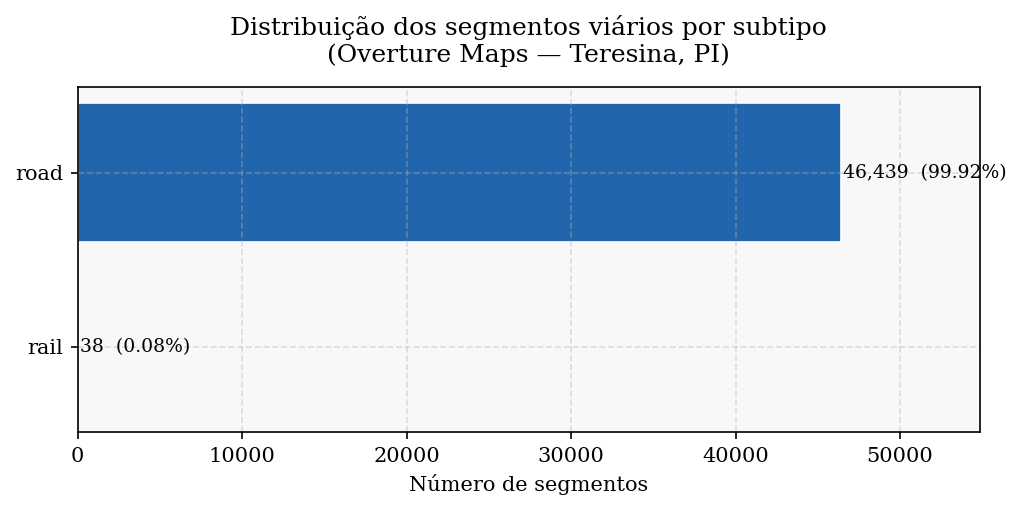

In [21]:
# Gera a Figura de distribuição dos subtipos (road vs rail)
contagem_plot = segments_gdf['subtype'].value_counts(dropna=False)
cores = ['#2166AC', '#D6604D', '#4DAC26']

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(contagem_plot.index.astype(str), contagem_plot.values, 
               color=cores[:len(contagem_plot)], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, contagem_plot.values):
    pct = val / total_bruto * 100
    ax.text(bar.get_width() + total_bruto * 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.2f}%)', va='center', fontsize=9)

ax.set_xlabel('Número de segmentos')
ax.set_title('Distribuição dos segmentos viários por subtipo\n(Overture Maps — Teresina, PI)', pad=12)
ax.set_xlim(0, total_bruto * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_1_distribuicao_subtipo.png', bbox_inches='tight')
plt.show()

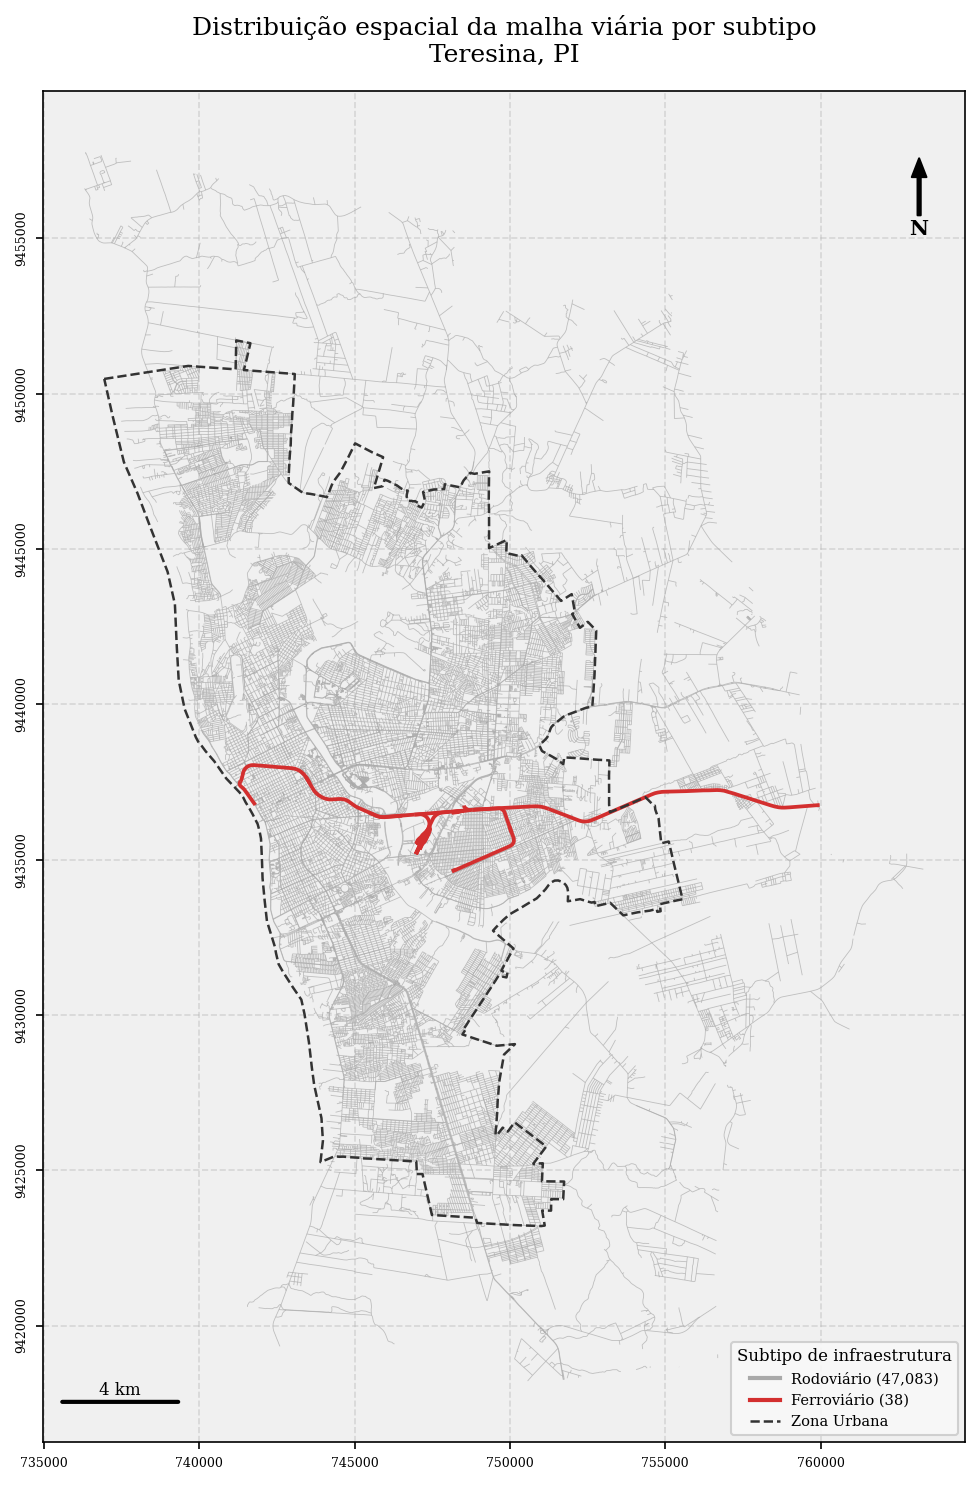

✅ Mapa de subtipos salvo.


In [32]:
import contextily as cx

# ── Mapa de Subtipos de Via (Rodoviário vs. Ferroviário) ─────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

# Moldura da zona urbana
zu_gdf.boundary.plot(ax=ax, color='#333333', linewidth=1.2, linestyle='--', zorder=5)

# Definindo estilos específicos para dar destaque à minoria (rail)
ESTILO_SUBTYPE = {
    'road': {'cor': '#A9A9A9', 'lw': 0.4, 'alpha': 0.7, 'zorder': 2, 'nome': 'Rodoviário'},
    'rail': {'cor': '#D32F2F', 'lw': 1.8, 'alpha': 1.0, 'zorder': 4, 'nome': 'Ferroviário'}
}

# Vias por subtipo
for subtipo, estilo in ESTILO_SUBTYPE.items():
    subset = segments_gdf[segments_gdf['subtype'] == subtipo]
    if len(subset) > 0:
        subset.plot(
            ax=ax, 
            color=estilo['cor'], 
            linewidth=estilo['lw'], 
            alpha=estilo['alpha'], 
            zorder=estilo['zorder']
        )

# Legenda manual dinâmica
legend_elements = [
    Line2D([0], [0], color=estilo['cor'], linewidth=2, 
           label=f'{estilo["nome"]} ({len(segments_gdf[segments_gdf["subtype"]==subtipo]):,})')
    for subtipo, estilo in ESTILO_SUBTYPE.items()
] + [Line2D([0], [0], color='#333333', linewidth=1.2, linestyle='--', label='Zona Urbana')]

ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
          framealpha=0.9, title='Subtipo de infraestrutura', title_fontsize=8)

ax.set_title(
    'Distribuição espacial da malha viária por subtipo\nTeresina, PI',
    fontsize=12, pad=14
)
ax.set_facecolor('#F0F0F0')
# ax.set_xlabel('Este (m)', fontsize=8)
# ax.set_ylabel('Norte (m)', fontsize=8)

# ── CORREÇÕES DOS EIXOS ──────────────────────────────────────────────────────
# Desativa a notação científica e reduz o tamanho da fonte
ax.ticklabel_format(style='plain', axis='both')
ax.tick_params(axis='both', labelsize=6)

# Rotaciona os números do eixo Y em 90 graus
ax.tick_params(axis='y', labelrotation=90)

# Força o alinhamento central de cada número com o seu respectivo tracinho
for label in ax.get_yticklabels():
    label.set_verticalalignment('center')
# ─────────────────────────────────────────────────────────────────────────────

# Escala numérica simples
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
respiro = 500
ax.annotate('', xy=(x0 + respiro + 4000, y0 + (y1-y0)*0.03),
            xytext=(x0 + respiro, y0 + (y1-y0)*0.03),
            arrowprops=dict(arrowstyle='-', lw=2, color='k'))
ax.text(x0 + respiro + 2000, y0 + (y1-y0)*0.035, '4 km', ha='center', fontsize=8)

# ── SETA DE NORTE (Rosa dos Ventos) ──────────────────────────────────────────
# xycoords='axes fraction' usa a proporção do quadro (0,0 é o canto inferior esquerdo; 1,1 é o superior direito)
ax.annotate(
    'N', 
    xy=(0.95, 0.95),          # Onde a ponta da seta vai ficar
    xytext=(0.95, 0.89),      # Onde a base da seta (e o texto) vai ficar
    xycoords='axes fraction', 
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', edgecolor='black', width=1.5, headwidth=7, headlength=9),
    ha='center', 
    va='bottom', 
    fontsize=10, 
    fontfamily='serif',       # Usa uma fonte clássica que combina com mapas
    fontweight='bold'
)

plt.tight_layout()
# Salva o arquivo
plt.savefig(FIGURAS_PATH / 'mapa_subtipo_viario.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Mapa de subtipos salvo.')

In [33]:
# Configuração de diretórios e variáveis
diretorio_saida = Path("../dados/brutos/ibge")
diretorio_saida.mkdir(parents=True, exist_ok=True)

codigo_teresina = "2211001"
crs_metrico = 31983

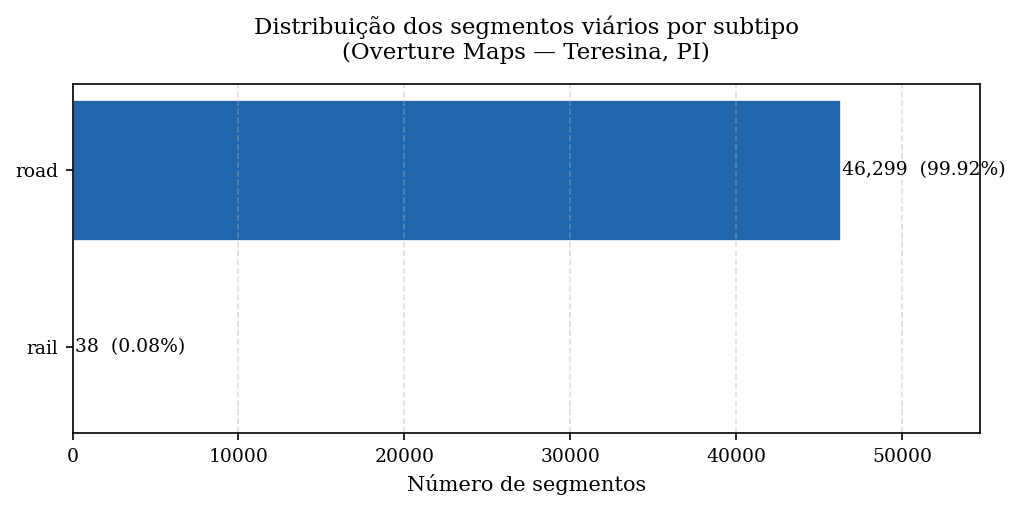

✅ Fig. 4.1 salva.


In [8]:
# ── Fig. 4.1 — Distribuição de segmentos por subtipo ─────────────────────────
# Objetivo: mostrar que 99,9% dos segmentos são road, justificando o filtro.

contagem_plot = segments_gdf['subtype'].value_counts(dropna=False)
cores = ['#2166AC', '#D6604D', '#4DAC26']

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(
    contagem_plot.index.astype(str),
    contagem_plot.values,
    color=cores[:len(contagem_plot)],
    edgecolor='white', linewidth=0.8
)

# Rótulos de valor
for bar, val in zip(bars, contagem_plot.values):
    pct = val / total_bruto * 100
    ax.text(bar.get_width() + total_bruto * 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.2f}%)', va='center', fontsize=9)

ax.set_xlabel('Número de segmentos')
ax.set_title('Distribuição dos segmentos viários por subtipo\n(Overture Maps — Teresina, PI)', pad=12)
ax.set_xlim(0, total_bruto * 1.18)
ax.invert_yaxis()
ax.set_facecolor('white')
ax.grid(axis='x', alpha=0.4, linestyle='--')
ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_1_distribuicao_subtipo.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.1 salva.')

In [ ]:
road_gdf.to_file(PROCESSED_PATH / 'zonaUrbanaReal_3km_road.geojson', driver='GeoJSON')

## Caso já tenho filtrado as 'road', inicie as 3 primeiras células e está para continuar


In [ ]:
road_gdf = gpd.read_file(PROCESSED_PATH / 'zonaUrbanaReal_3km_road.geojson')

C:\Users\felipe\workspace\code_dissertacao\mapeprof-accessibility-ubs\.venv\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'level_rules' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


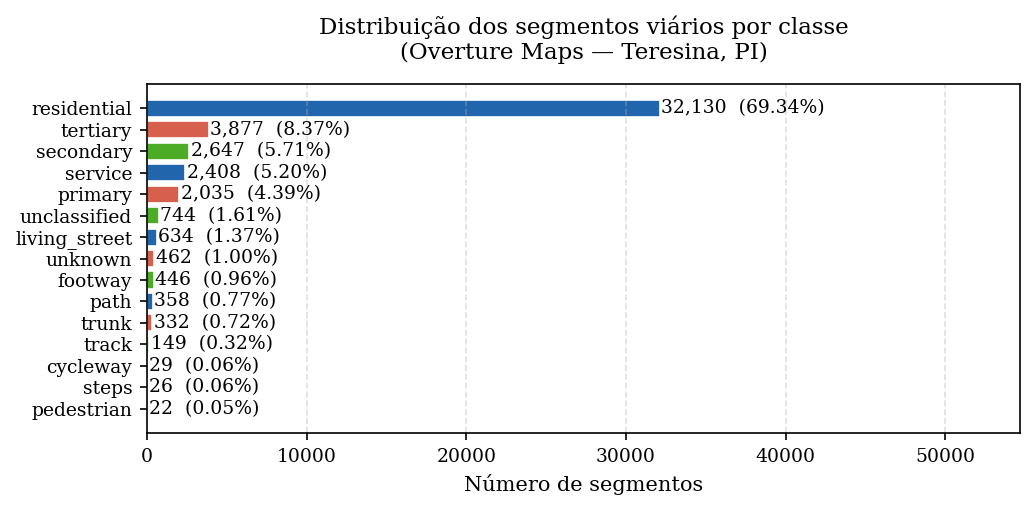

✅ Fig. 4.2 salva.


In [10]:
# ── Fig. 4.2 — Distribuição de segmentos por classe ─────────────────────────

contagem_plot = road_gdf['class'].value_counts(dropna=False)
cores = ['#2166AC', '#D6604D', '#4DAC26']

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(
    contagem_plot.index.astype(str),
    contagem_plot.values,
    color=cores[:len(contagem_plot)],
    edgecolor='white', linewidth=0.8
)

# Rótulos de valor
for bar, val in zip(bars, contagem_plot.values):
    pct = val / total_bruto * 100
    ax.text(bar.get_width() + total_bruto * 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.2f}%)', va='center', fontsize=9)

ax.set_xlabel('Número de segmentos')
ax.set_title('Distribuição dos segmentos viários por classe\n(Overture Maps — Teresina, PI)', pad=12)
ax.set_xlim(0, total_bruto * 1.18)
ax.invert_yaxis()
ax.set_facecolor('white')
ax.grid(axis='x', alpha=0.4, linestyle='--')
ax.grid(axis='y', alpha=0)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_2_distribuicao_classe.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.2 salva.')

---
## 4. Pré-processamento nativo Overture Maps

Os segmentos brutos da Overture Maps **não chegam prontos para análise de rede**.
É necessário aplicar `c2g.process_overture_segments()` antes de qualquer filtro
temático ou seleção de colunas. A função executa três operações:

1. **Connector splitting** — cada segmento longo é cortado nos pontos dos connectors,
   gerando arestas curtas com extremidades nos nós reais da rede. Sem isso,
   interseções não existem como nós e o grafo fica topologicamente incorreto,
   produzindo tempos de viagem imprecisos no NB 03.

2. **Endpoint clustering** — extremidades geometricamente próximas são snapped,
   eliminando lacunas que desconectariam ruas adjacentes no grafo.

3. **Barrier extraction** (opcional) — pontes e túneis são identificados via
   `level_rules`. Desativado aqui (`get_barriers=False`) pois não usamos
   `morphological_graph()` neste pipeline.

> ⚠️ A coluna `level_rules` **não pode ser removida antes desta etapa**.
> Por isso, a seleção de colunas ocorre somente na seção 9.

O output inclui as colunas `split_from` e `split_to`, que mapeiam diretamente
para os IDs dos nós do grafo (Referência: city2graph docs — *How to Use Overture Maps Like OSMnx*).

In [1]:
road_process_barriers = c2g.process_overture_segments(
    segments_gdf=road_gdf,
    get_barriers=True,                       # True somente se usar morphological_graph()
    connectors_gdf=connectors_gdf,
    threshold=3.0                            # tolerância de snap em metros
)

print(f"Processado {len(road_process_barriers)} segmentos de via")
print('✅ process_overture_segments concluído.')
print('   Topologia adicionada              : colunas split_from, split_to e length')
print(f'   Colunas disponíveis               : {road_process_barriers.columns.tolist()}')

NameError: name 'c2g' is not defined

In [12]:
print('--- CRS ---')
print(f'  antes : {road_gdf.crs}')
print(f'  depois: {road_process_barriers.crs}')

print('\n--- Bounds (minx, miny, maxx, maxy) ---')
print(f'  antes : {road_gdf.total_bounds}')
print(f'  depois: {road_process_barriers.total_bounds}')

print('\n--- Diferença de bounds (m, se ambos em EPSG:31983) ---')
diff = road_process_barriers.total_bounds - road_gdf.total_bounds
print(f'  Δ minx={diff[0]:+.2f}  Δ miny={diff[1]:+.2f}  Δ maxx={diff[2]:+.2f}  Δ maxy={diff[3]:+.2f}')

--- CRS ---
  antes : EPSG:31983
  depois: EPSG:31983

--- Bounds (minx, miny, maxx, maxy) ---
  antes : [ 737484.68509987 9418909.04617976  762583.96175291 9454737.92631553]
  depois: [ 737484.68509987 9418909.04617976  762583.96175291 9454737.92631553]

--- Diferença de bounds (m, se ambos em EPSG:31983) ---
  Δ minx=+0.00  Δ miny=+0.00  Δ maxx=+0.00  Δ maxy=+0.00


In [13]:
# Check the geometry types in the barrier_geometry column
geometry_types = road_process_barriers["barrier_geometry"].geom_type.value_counts()
print("\nBarrier geometry types:")
for geom_type, count in geometry_types.items():
    print(f"   - {geom_type}: {count:,}")


Barrier geometry types:
   - LineString: 51,918
   - MultiLineString: 169


In [14]:
road_process_barriers.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52165 entries, 0 to 52164
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      52165 non-null  object  
 1   names                   38859 non-null  object  
 2   subtype                 52165 non-null  object  
 3   class                   52165 non-null  object  
 4   subclass                2110 non-null   object  
 5   subclass_rules          2227 non-null   object  
 6   connectors              52165 non-null  object  
 7   rail_flags              0 non-null      object  
 8   road_surface            15323 non-null  object  
 9   road_flags              955 non-null    object  
 10  width_rules             772 non-null    object  
 11  level_rules             52165 non-null  object  
 12  access_restrictions     14099 non-null  object  
 13  speed_limits            6834 non-null   object  
 14  prohibited_tra

In [15]:
road_process_barriers.to_parquet(PROCESSED_PATH / "zonaUrbanaReal_3km_roadBarriers.parquet")

In [ ]:
# Converte a coluna extra de Objeto Geométrico para Texto (WKT)
road_process_barriers['geometry_wkt'] = road_process_barriers['barrier_geometry'].to_wkt()
# road_process_barriers.drop(labels='barrier_geometry', )

# Agora o GeoPandas tem apenas UMA coluna geométrica verdadeira, e salva normalmente
gdf.to_file("../dados/processados/zonaUrbanaReal_3km_roadBarriers.geojson", driver="GeoJSON")

# 
road_process_barriers.to_parquet(PROCESSED_PATH / "zonaUrbanaReal_3km_roadBarriers.parquet", )

In [8]:
road_process_barriers.head(10)

,id,names,subtype,class,subclass,subclass_rules,connectors,rail_flags,road_surface,road_flags,...,prohibited_transitions,routes,destinations,sources,version,geometry,split_from,split_to,length,barrier_geometry
0,6f2590c9-8634-4557-87d4-7af0ef480c69,None,road,primary,None,None,[{'connector_id': '6deac8b8-2f44-49e0-a725-229...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065983.879 -1534877.712, -10065...",NaN,NaN,99.537305,"LINESTRING (-10065983.879 -1534877.712, -10065..."
1,3126b0c8-ba5c-4998-9a0b-5a6475d6861a,"{'primary': 'Avenida Maranhão', 'common': None...",road,secondary,None,None,[{'connector_id': '9fe47c84-e28a-4716-b5c5-f23...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10073254.085 -1508361.032, -10072...",NaN,NaN,510.850374,"LINESTRING (-10073254.085 -1508361.032, -10072..."
2,895a0223-bbd3-40c3-ba5c-fb7076c8fce1,None,road,residential,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,None,None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100658...",NaN,NaN,154.947600,"LINESTRING (-10065970.52 -1534779.076, -100658..."
3,1b21f057-464d-4e85-b650-d595c9cfa0af,None,road,primary,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,898.876803,"LINESTRING (-10065966.023 -1534745.76, -100659..."
4,29090412-2046-4011-8221-ffd287b0d00b,"{'primary': 'Rua Quatro Parque Saci', 'common'...",road,residential,None,None,[{'connector_id': '0ff8607d-8bb2-434e-aa64-d49...,None,None,None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10070965.715 -1510736.253, -10070...",NaN,NaN,199.085768,"LINESTRING (-10070965.715 -1510736.253, -10070..."
5,cb682c82-1a5e-476a-af63-858763615409,"{'primary': 'Rua Atlantida', 'common': None, '...",road,residential,None,None,[{'connector_id': '9ec5159b-640c-44a1-8435-920...,None,None,None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071117.176 -1510240.074, -10071...",NaN,NaN,264.538239,"LINESTRING (-10071117.176 -1510240.074, -10071..."
6,b1117c8b-b2a4-4616-aa23-a25a256ef4b6,None,road,residential,None,None,[{'connector_id': '1957f5dd-e1ef-4be4-b3a5-198...,None,None,None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071069.301 -1510089.845, -10071...",NaN,NaN,156.066074,"LINESTRING (-10071069.301 -1510089.845, -10071..."
7,e88332fc-5fde-47ee-930b-0a472c9de46a,None,road,residential,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,None,None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,666.745722,"LINESTRING (-10065966.023 -1534745.76, -100659..."
8,685401d6-584c-4818-a660-a74b4fc719dd,None,road,primary,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100659...",NaN,NaN,33.617320,"LINESTRING (-10065970.52 -1534779.076, -100659..."
9,71c4b530-66f4-42b5-9bbe-1b1f3de68e55,"{'primary': 'Rua Um', 'common': None, 'rules':...",road,residential,None,None,[{'connector_id': '9a58069b-a05b-4278-a562-837...,None,"[{'value': 'unpaved', 'between': None}]",None,...,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",2,"LINESTRING (-10072505.353 -1509260.269, -10072...",NaN,NaN,1516.892917,"LINESTRING (-10072505.353 -1509260.269, -10072..."


In [11]:
print(road_process_barriers.geometry.name)

geometry


---
## 5. Extração de atributos aninhados

A Overture Maps armazena alguns atributos como **listas ou dicionários** dentro de células,
em vez de valores escalares diretos. Precisamos extrair dois desses atributos:

- `names` → estrutura `{'primary': 'Av. Frei Serafim', ...}` → extrair o campo `'primary'`
- `road_surface` → estrutura `[{'value': 'paved', 'between': None}]` → extrair o campo `'value'`

### 5.1 Nome das vias

In [6]:
def _coerce_aninhado(valor):
    """
    Converte um valor possivelmente serializado como string (caso típico ao
    ler um GeoPackage) na estrutura Python original (dict ou list).

    Retorna o objeto parseado, ou None se o valor for ausente/ilegível.
    """
    if valor is None:
        return None
    if isinstance(valor, (dict, list)):
        return valor
    if isinstance(valor, str):
        s = valor.strip()
        if not s or s.lower() in ('none', 'nan', 'null'):
            return None
        # ast.literal_eval lida com repr Python (aspas simples, None)
        # json.loads lida com JSON (aspas duplas, null/true/false)
        for parser in (ast.literal_eval, json.loads):
            try:
                return parser(s)
            except (ValueError, SyntaxError):
                continue
    return None


def extrair_nome_via(valor):
    """
    Extrai o nome primário de uma via a partir da estrutura aninhada da
    Overture Maps. (colunas 'names' ou 'routes')

    Estrutura esperada em 'names': {'primary': 'Nome da Via', 'common': ..., 'rules': ...}
    Estrutura esperada em 'routes' {{'ref': 'BR-343', ...}'}

    Aceita tanto dict (caso GeoJSON) quanto string serializada (caso
    GeoPackage), pois o driver GPKG armazena estruturas aninhadas como texto.

    Parâmetros
    ----------
    valor : dict | str | None
        Valor da célula na coluna 'names'.

    Retorna
    -------
    str | None
        Nome primário da via ou None se ausente.
    """
    obj = _coerce_aninhado(valor)

    #CASO 1: Estrutura da coluna 'names' (dicionário)
    if isinstance(obj, dict):
        nome = obj.get('primary')
        return nome if isinstance(nome, str) and nome.strip() else None

    #Caso 2: estrutura da coluna 'routes' (lista de dicionários')  
    elif isinstance(obj, list):
        refs=[]   
        for item in obj:
            if isinstance(item,dict):
                ref = item.get('ref')
                # adiciona à lista se for uma string válida e não vazia$#   
                if isinstance(ref, str) and ref.strip():
                    refs.appenf(ref.strip())

        # Se encontrou alguma referência , junta todas com uma barra
        # #Útil caso a via pertença a mais de uma rota, ex: 'BR-343 / PI-112')
        # IF 
        #             
        if refs:
            return " / ".join(refs)
            
    return None

In [7]:
road_process_barriers['nomes_vias'] = road_process_barriers['names'].apply(extrair_nome_via)

n_com_nome = road_process_barriers['nomes_vias'].notna().sum()
print('✅ Nomes extraídos.')
print(f'   Vias com nome  : {n_com_nome:,} ({n_com_nome/len(road_process_barriers)*100:.1f}%)')
print(f'   Vias sem nome  : {len(road_process_barriers)-n_com_nome:,} ({(len(road_process_barriers)-n_com_nome)/len(road_process_barriers)*100:.1f}%)')

✅ Nomes extraídos.
   Vias com nome  : 38,859 (74.5%)
   Vias sem nome  : 13,306 (25.5%)


In [8]:
road_process_barriers.head(10)

,id,names,subtype,class,subclass,subclass_rules,connectors,rail_flags,road_surface,road_flags,...,routes,destinations,sources,version,geometry,split_from,split_to,length,barrier_geometry,nomes_vias
0,6f2590c9-8634-4557-87d4-7af0ef480c69,None,road,primary,None,None,[{'connector_id': '6deac8b8-2f44-49e0-a725-229...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065983.879 -1534877.712, -10065...",NaN,NaN,99.537305,"LINESTRING (-10065983.879 -1534877.712, -10065...",None
1,3126b0c8-ba5c-4998-9a0b-5a6475d6861a,"{'primary': 'Avenida Maranhão', 'common': None...",road,secondary,None,None,[{'connector_id': '9fe47c84-e28a-4716-b5c5-f23...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10073254.085 -1508361.032, -10072...",NaN,NaN,510.850374,"LINESTRING (-10073254.085 -1508361.032, -10072...",Avenida Maranhão
2,895a0223-bbd3-40c3-ba5c-fb7076c8fce1,None,road,residential,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,None,None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100658...",NaN,NaN,154.947600,"LINESTRING (-10065970.52 -1534779.076, -100658...",None
3,1b21f057-464d-4e85-b650-d595c9cfa0af,None,road,primary,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,898.876803,"LINESTRING (-10065966.023 -1534745.76, -100659...",None
4,29090412-2046-4011-8221-ffd287b0d00b,"{'primary': 'Rua Quatro Parque Saci', 'common'...",road,residential,None,None,[{'connector_id': '0ff8607d-8bb2-434e-aa64-d49...,None,None,None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10070965.715 -1510736.253, -10070...",NaN,NaN,199.085768,"LINESTRING (-10070965.715 -1510736.253, -10070...",Rua Quatro Parque Saci
5,cb682c82-1a5e-476a-af63-858763615409,"{'primary': 'Rua Atlantida', 'common': None, '...",road,residential,None,None,[{'connector_id': '9ec5159b-640c-44a1-8435-920...,None,None,None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071117.176 -1510240.074, -10071...",NaN,NaN,264.538239,"LINESTRING (-10071117.176 -1510240.074, -10071...",Rua Atlantida
6,b1117c8b-b2a4-4616-aa23-a25a256ef4b6,None,road,residential,None,None,[{'connector_id': '1957f5dd-e1ef-4be4-b3a5-198...,None,None,None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071069.301 -1510089.845, -10071...",NaN,NaN,156.066074,"LINESTRING (-10071069.301 -1510089.845, -10071...",None
7,e88332fc-5fde-47ee-930b-0a472c9de46a,None,road,residential,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,None,None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,666.745722,"LINESTRING (-10065966.023 -1534745.76, -100659...",None
8,685401d6-584c-4818-a660-a74b4fc719dd,None,road,primary,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,"[{'value': 'paved', 'between': None}]",None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100659...",NaN,NaN,33.617320,"LINESTRING (-10065970.52 -1534779.076, -100659...",None
9,71c4b530-66f4-42b5-9bbe-1b1f3de68e55,"{'primary': 'Rua Um', 'common': None, 'rules':...",road,residential,None,None,[{'connector_id': '9a58069b-a05b-4278-a562-837...,None,"[{'value': 'unpaved', 'between': None}]",None,...,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",2,"LINESTRING (-10072505.353 -1509260.269, -10072...",NaN,NaN,1516.892917,"LINESTRING (-10072505.353 -1509260.269, -10072...",Rua Um


### 5.2 Tipo de superfície

In [9]:
def extrair_superficie(valor):
    """
    Extrai o tipo de superfície a partir da estrutura aninhada da Overture Maps.

    Estrutura esperada: [{'value': 'paved', 'between': None}, ...]

    Aceita tanto list (caso GeoJSON) quanto string serializada (caso
    GeoPackage), pois o driver GPKG armazena estruturas aninhadas como texto.

    Parâmetros
    ----------
    valor : list | str | None
        Valor da célula na coluna 'road_surface'.

    Retorna
    -------
    str
        Tipo de superfície ('paved', 'unpaved', 'gravel', etc.) ou 'unknown'.
    """
    obj = _coerce_aninhado(valor)
    if isinstance(obj, list) and obj:
        primeiro = obj[0]
        if isinstance(primeiro, dict):
            return primeiro.get('value', 'unknown') or 'unknown'
    return 'unknown'

In [10]:
road_process_barriers['surface_clean'] = road_process_barriers['road_surface'].apply(extrair_superficie)

print('✅ Superfície extraída.')
print('\nDistribuição:')
print(road_process_barriers['surface_clean'].value_counts().to_string())

✅ Superfície extraída.

Distribuição:
surface_clean
unknown          36944
paved            12579
unpaved           1259
paving_stones      821
dirt               556
gravel               6


In [11]:
road_process_barriers.head(10)

,id,names,subtype,class,subclass,subclass_rules,connectors,rail_flags,road_surface,road_flags,...,destinations,sources,version,geometry,split_from,split_to,length,barrier_geometry,nomes_vias,surface_clean
0,6f2590c9-8634-4557-87d4-7af0ef480c69,None,road,primary,None,None,[{'connector_id': '6deac8b8-2f44-49e0-a725-229...,None,"[{'value': 'paved', 'between': None}]",None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065983.879 -1534877.712, -10065...",NaN,NaN,99.537305,"LINESTRING (-10065983.879 -1534877.712, -10065...",None,paved
1,3126b0c8-ba5c-4998-9a0b-5a6475d6861a,"{'primary': 'Avenida Maranhão', 'common': None...",road,secondary,None,None,[{'connector_id': '9fe47c84-e28a-4716-b5c5-f23...,None,"[{'value': 'paved', 'between': None}]",None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10073254.085 -1508361.032, -10072...",NaN,NaN,510.850374,"LINESTRING (-10073254.085 -1508361.032, -10072...",Avenida Maranhão,paved
2,895a0223-bbd3-40c3-ba5c-fb7076c8fce1,None,road,residential,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,None,None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100658...",NaN,NaN,154.947600,"LINESTRING (-10065970.52 -1534779.076, -100658...",None,unknown
3,1b21f057-464d-4e85-b650-d595c9cfa0af,None,road,primary,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,"[{'value': 'paved', 'between': None}]",None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,898.876803,"LINESTRING (-10065966.023 -1534745.76, -100659...",None,paved
4,29090412-2046-4011-8221-ffd287b0d00b,"{'primary': 'Rua Quatro Parque Saci', 'common'...",road,residential,None,None,[{'connector_id': '0ff8607d-8bb2-434e-aa64-d49...,None,None,None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10070965.715 -1510736.253, -10070...",NaN,NaN,199.085768,"LINESTRING (-10070965.715 -1510736.253, -10070...",Rua Quatro Parque Saci,unknown
5,cb682c82-1a5e-476a-af63-858763615409,"{'primary': 'Rua Atlantida', 'common': None, '...",road,residential,None,None,[{'connector_id': '9ec5159b-640c-44a1-8435-920...,None,None,None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071117.176 -1510240.074, -10071...",NaN,NaN,264.538239,"LINESTRING (-10071117.176 -1510240.074, -10071...",Rua Atlantida,unknown
6,b1117c8b-b2a4-4616-aa23-a25a256ef4b6,None,road,residential,None,None,[{'connector_id': '1957f5dd-e1ef-4be4-b3a5-198...,None,None,None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10071069.301 -1510089.845, -10071...",NaN,NaN,156.066074,"LINESTRING (-10071069.301 -1510089.845, -10071...",None,unknown
7,e88332fc-5fde-47ee-930b-0a472c9de46a,None,road,residential,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,None,None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065966.023 -1534745.76, -100659...",NaN,NaN,666.745722,"LINESTRING (-10065966.023 -1534745.76, -100659...",None,unknown
8,685401d6-584c-4818-a660-a74b4fc719dd,None,road,primary,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,"[{'value': 'paved', 'between': None}]",None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (-10065970.52 -1534779.076, -100659...",NaN,NaN,33.617320,"LINESTRING (-10065970.52 -1534779.076, -100659...",None,paved
9,71c4b530-66f4-42b5-9bbe-1b1f3de68e55,"{'primary': 'Rua Um', 'common': None, 'rules':...",road,residential,None,None,[{'connector_id': '9a58069b-a05b-4278-a562-837...,None,"[{'value': 'unpaved', 'between': None}]",None,...,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",2,"LINESTRING (-10072505.353 -1509260.269, -10072...",NaN,NaN,1516.892917,"LINESTRING (-10072505.353 -1509260.269, -10072...",Rua Um,unpaved


# Velocidade do trecho

In [12]:
def extrair_velocidade_maxima(valor):
    """
    Extrai o valor numérico da velocidade máxima ('max_speed' -> 'value')
    a partir da estrutura aninhada da Overture Maps.
    
    Estrutura esperada: 
    [{'max_speed': {'value': 60, 'unit': 'km/h'}, ...}]
    
    Parâmetros
    ----------
    valor : list | str | None
        Valor da célula na coluna que contém as regras de velocidade.
        
    Retorna
    -------
    float | None
        O valor da velocidade máxima ou None se ausente/inválido.
    """
    # 1. Coerção: Garante que strings (GeoPackage) virem listas/dicts reais
    if pd.isna(valor) or valor is None:
        return None
        
    obj = valor
    if isinstance(obj, str):
        s = obj.strip()
        if not s or s.lower() in ('none', 'nan', 'null'):
            return None
        for parser in (ast.literal_eval, json.loads):
            try:
                obj = parser(s)
                break
            except (ValueError, SyntaxError):
                continue

    # 2. Extração: Varre a estrutura para encontrar os valores
    velocidades = []
    
    # Caso seja uma lista de regras (padrão Overture)
    if isinstance(obj, list):
        for item in obj:
            if isinstance(item, dict):
                max_speed = item.get('max_speed')
                if isinstance(max_speed, dict):
                    val = max_speed.get('value')
                    if val is not None:
                        try:
                            velocidades.append(float(val))
                        except (ValueError, TypeError):
                            pass
                            
    # Caso seja um dicionário direto (fallback)
    elif isinstance(obj, dict):
        max_speed = obj.get('max_speed')
        if isinstance(max_speed, dict):
            val = max_speed.get('value')
            if val is not None:
                try:
                    velocidades.append(float(val))
                except (ValueError, TypeError):
                    pass

    # 3. Retorno: Devolve a maior velocidade encontrada (ideal para roteamento)
    if velocidades:
        return max(velocidades)
        
    return None

In [13]:
# Cria uma nova coluna 'velocidade_max' contendo apenas os números (em formato float)
road_process_barriers['velocidade_max'] = road_process_barriers['speed_limits'].apply(extrair_velocidade_maxima)

In [14]:
# Se quiser visualizar as 5 primeiras linhas para conferir o resultado:
print(road_process_barriers[['speed_limits', 'velocidade_max']].head())

                                        speed_limits  velocidade_max
0                                               None             NaN
1  [{'min_speed': None, 'max_speed': {'value': 60...            60.0
2                                               None             NaN
3                                               None             NaN
4                                               None             NaN


In [15]:
road_process_barriers.to_parquet(PROCESSED_PATH / "zonaUrbanaReal_3km_roadBarriers.parquet")

# Começar daqui

In [ ]:
road_process_barriers = gpd.read_parquet(PROCESSED_PATH / 'zonaUrbanaReal_3km_roadBarriers.parquet')


<Axes: >

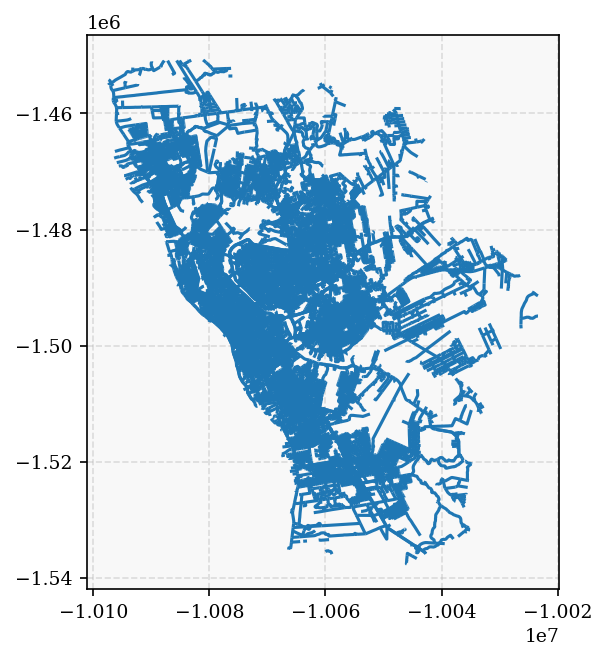

In [16]:
road_process_barriers.plot()

### Fig. 4.2 — Distribuição do tipo de superfície viária

In [18]:
# Analisando a distribuição do tipo de superfície da via
contagem_superficie = road_process_barriers['surface_clean'].value_counts(dropna=False,)
total_bruto = len(contagem_superficie)

print('--- Distribuição por subtipo (antes do filtro) ---')
for subtipo, qtd in contagem_superficie.items():
    print(f'  • {str(subtipo):<12}: {qtd:>7,}  ({qtd/total_bruto*100:.3f}%)')
print(f'    Total       : {total_bruto:>7,}')

--- Distribuição por subtipo (antes do filtro) ---
  • unknown     :  36,944  (615733.333%)
  • paved       :  12,579  (209650.000%)
  • unpaved     :   1,259  (20983.333%)
  • paving_stones:     821  (13683.333%)
  • dirt        :     556  (9266.667%)
  • gravel      :       6  (100.000%)
    Total       :       6


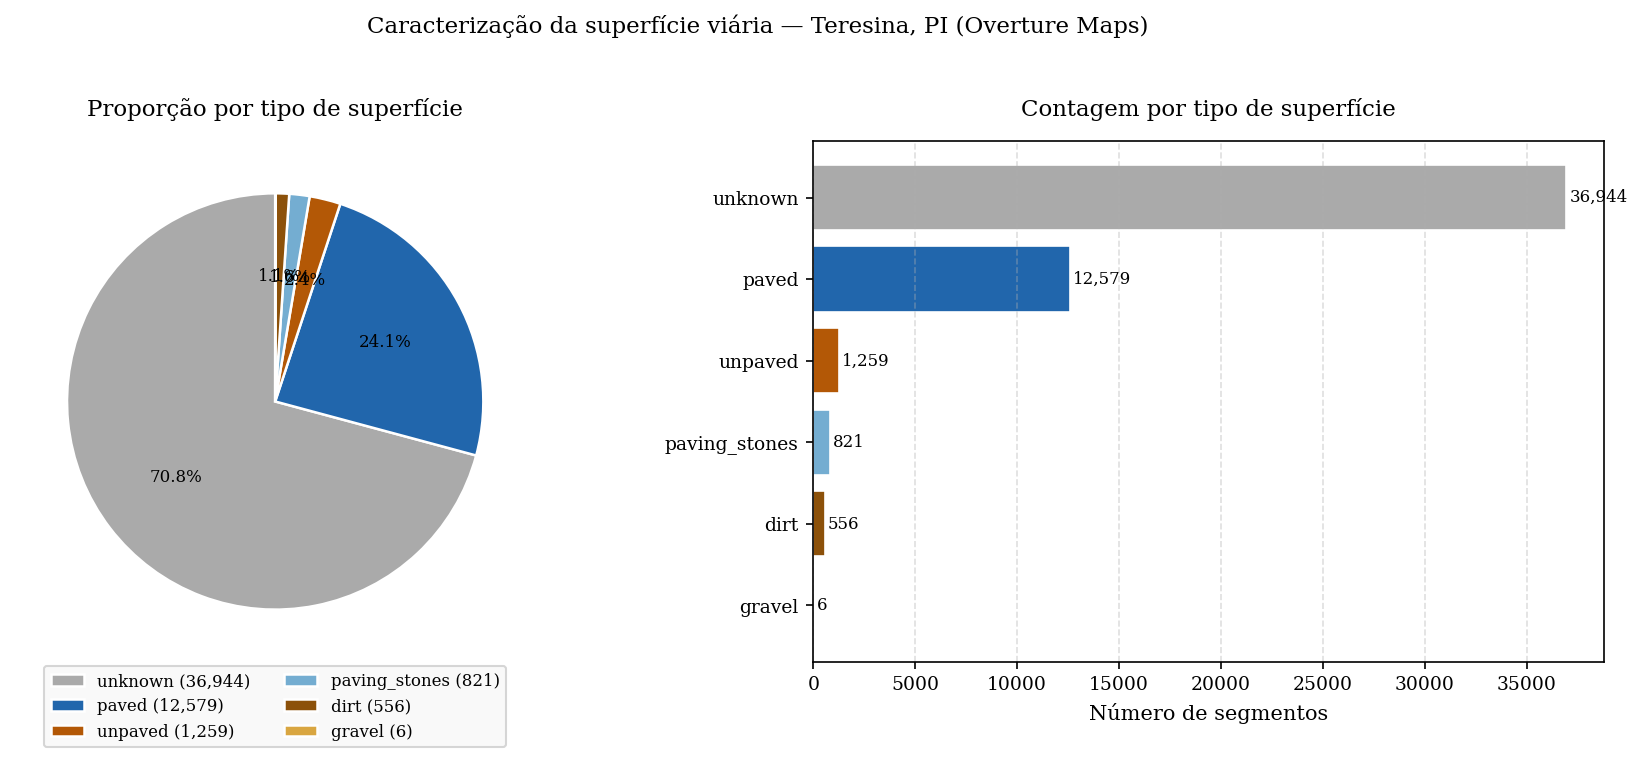

✅ Fig. 4.4 salva.


In [19]:
# ── Fig. 4.2 — Distribuição de superfície (pizza + barras) ───────────────────
# Revela a proporção de vias sem pavimentação — dado relevante para justificar
# o uso de impedâncias diferenciadas no NB 03.

contagem_surf = road_process_barriers['surface_clean'].value_counts()

CORES_SURF = {
    'paved'         : '#2166AC',
    'unpaved'       : '#B35806',
    'gravel'        : '#D9A641',
    'dirt'          : '#8C510A',
    'paving_stones' : '#74ADD1',
    'unknown'       : '#AAAAAA',
}
cores_lista = [CORES_SURF.get(s, '#CCCCCC') for s in contagem_surf.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Pizza ---
wedges, texts, autotexts = ax1.pie(
    contagem_surf.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=cores_lista,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('Proporção por tipo de superfície', pad=12)
ax1.legend(
    wedges, [f'{s} ({v:,})' for s, v in contagem_surf.items()],
    loc='lower center', bbox_to_anchor=(0.5, -0.18),
    fontsize=8, ncol=2
)

# --- Barras horizontais ---
bars = ax2.barh(
    contagem_surf.index.astype(str),
    contagem_surf.values,
    color=cores_lista, edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, contagem_surf.values):
    ax2.text(bar.get_width() + len(road_process_barriers)*0.003, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8)
ax2.set_xlabel('Número de segmentos')
ax2.set_title('Contagem por tipo de superfície', pad=12)
ax2.invert_yaxis()
ax2.set_facecolor('white')
ax2.grid(axis='x', alpha=0.4, linestyle='--')
ax2.grid(axis='y', alpha=0)

fig.suptitle(
    'Caracterização da superfície viária — Teresina, PI (Overture Maps)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_4_superficie_distribuicao.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.4 salva.')


### Fig. 4.3 — Mapa: superfície pavimentada vs não-pavimentada

In [20]:
road_process_barriers['surf_group'] = road_process_barriers['surface_clean'].map({
    'paved'         : 'Pavimentada',
    'paving_stones' : 'Pavimentada',
    'unpaved'       : 'Não pavimentada',
    'gravel'        : 'Não pavimentada',
    'dirt'          : 'Não pavimentada',
    'unknown'       : 'Desconhecida',
})
road_process_barriers['surf_group'] = road_process_barriers['surf_group'].fillna('Desconhecida')

CORES_GROUP = {
    'Pavimentada'      : '#2166AC',
    'Não pavimentada'  : '#B35806',
    'Desconhecida'     : '#CCCCCC',
}

In [27]:
road_process_barriers.to_crs(CRS_METRICO, inplace=True)

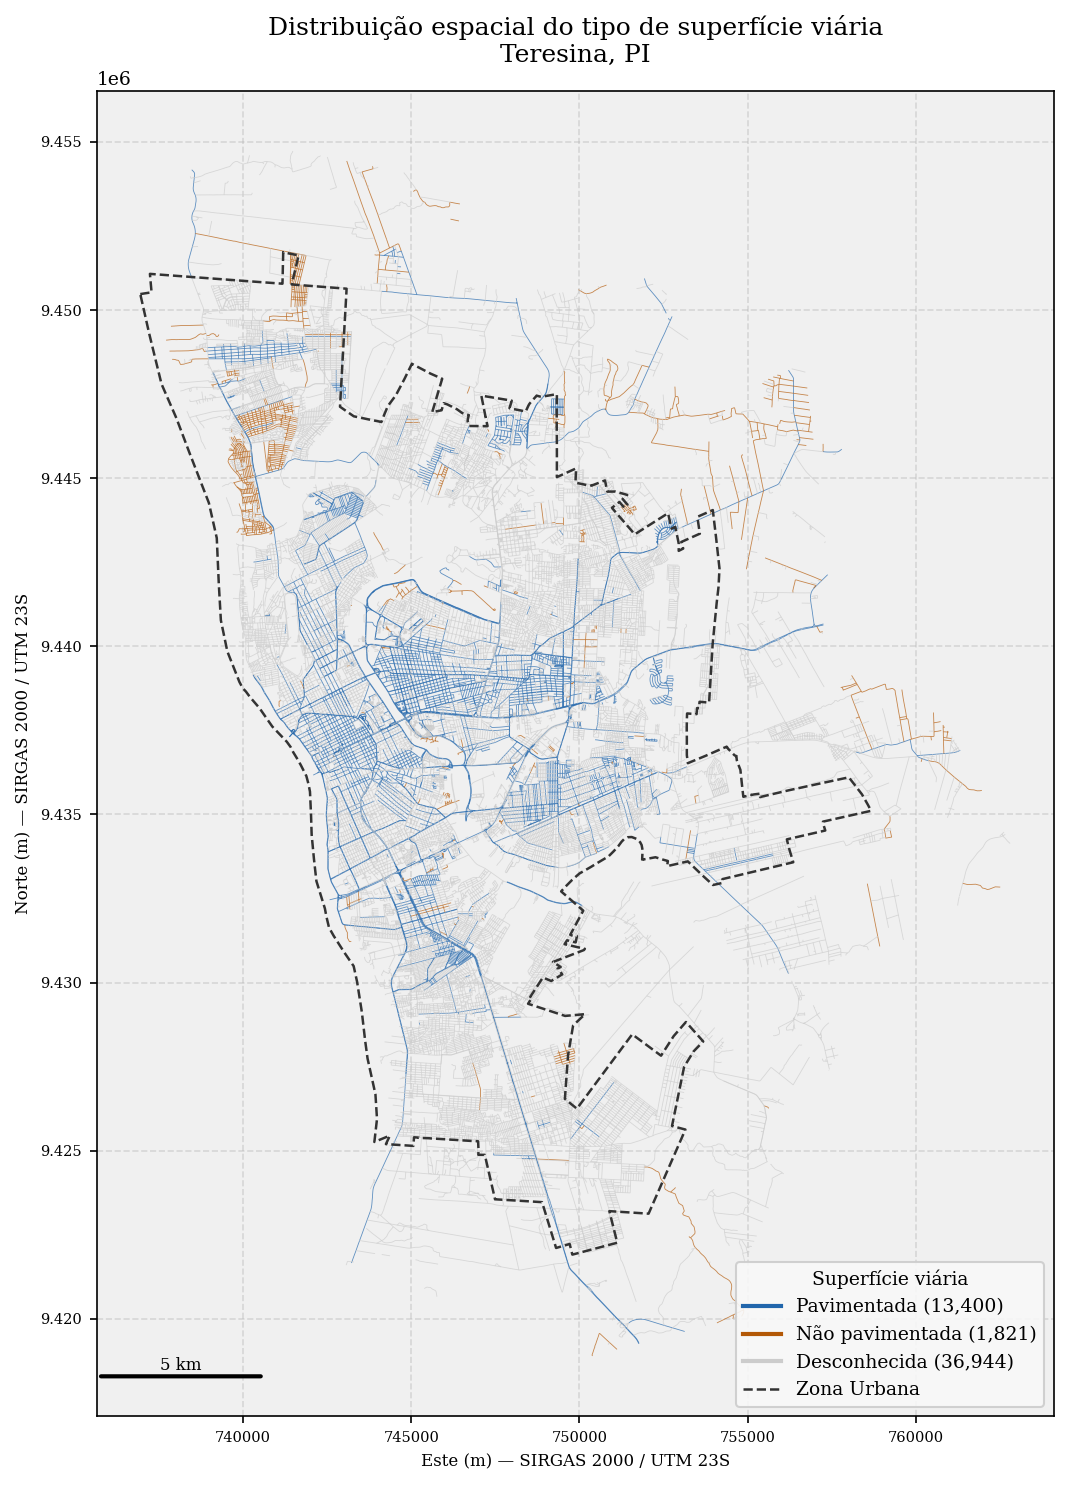

✅ Fig. 4.5 salva.


In [28]:
# ── Fig. 4.5 — Mapa de superfície viária ─────────────────────────────────────
# Evidencia a distribuição espacial das vias sem pavimentação, concentradas
# na periferia — dado que dialoga com a hipótese H2 (desigualdade territorial).

fig, ax = plt.subplots(figsize=(10, 10))

# Moldura da zona urbana
zu_gdf.boundary.plot(ax=ax, color='#333333', linewidth=1.2, linestyle='--', zorder=5)

# Vias por grupo de superfície
for grupo, cor in CORES_GROUP.items():
    subset = road_process_barriers[road_process_barriers['surf_group'] == grupo]
    if len(subset) > 0:
        subset.plot(ax=ax, color=cor, linewidth=0.4, alpha=0.7, zorder=2)

# Legenda manual
legend_elements = [
    Line2D([0], [0], color=cor, linewidth=2, label=f'{g} ({len(road_process_barriers[road_process_barriers["surf_group"]==g]):,})')
    for g, cor in CORES_GROUP.items()
] + [Line2D([0], [0], color='#333333', linewidth=1.2, linestyle='--', label='Zona Urbana')]

ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          framealpha=0.9, title='Superfície viária', title_fontsize=9)

ax.set_title(
    'Distribuição espacial do tipo de superfície viária\nTeresina, PI',
    fontsize=12, pad=14
)
ax.set_facecolor('#F0F0F0')
ax.set_xlabel('Este (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.set_ylabel('Norte (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.tick_params(labelsize=7)

# Escala numérica simples (sem cartopy)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
ax.annotate('', xy=(x0 + 5000, y0 + (y1-y0)*0.03),
            xytext=(x0, y0 + (y1-y0)*0.03),
            arrowprops=dict(arrowstyle='-', lw=2, color='k'))
ax.text(x0 + 2500, y0 + (y1-y0)*0.035, '5 km', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_5_mapa_superficie.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.5 salva.')


---
## 6. Engenharia de features geométricas

Duas features geométricas são calculadas para uso como entrada da GNN no NB 02.2:

| Feature | Descrição | Faixa de valores |
|---|---|---|
| `length` | Comprimento do segmento em metros | > 0 |
| `linearity` | Razão entre distância euclidiana ponta-a-ponta e comprimento real | 0 a 1 (1 = reta perfeita) |

A linearidade captura a **tortuosidade** da via: valores próximos a 0 indicam segmentos
muito curvos ou em zigue-zague; valores próximos a 1 indicam vias retilíneas (típico de
avenidas e rodovias).

In [29]:
def calcular_linearidade(geom):
    """
    Calcula a linearidade de um segmento de via.

    Definida como a razão entre a distância euclidiana do ponto inicial ao
    ponto final e o comprimento real do segmento. Valores próximos a 1
    indicam vias retilíneas; valores próximos a 0 indicam alta tortuosidade.

    Parâmetros
    ----------
    geom : shapely.geometry.LineString
        Geometria do segmento viário.

    Retorna
    -------
    float
        Linearidade no intervalo [0, 1].
    """
    try:
        distancia_euclidiana = Point(geom.coords[0]).distance(Point(geom.coords[-1]))
        return distancia_euclidiana / geom.length if geom.length > 0 else 0.0
    except Exception:
        return 0.0

In [30]:
road_process_barriers['linearity'] = road_process_barriers.geometry.apply(calcular_linearidade)

# Cópia de segurança da classe original antes que a GNN (NB 02.2) a modifique
road_process_barriers['classe_original'] = road_process_barriers['class'].copy()

print('✅ Features geométricas calculadas.')
print()
print(road_process_barriers[['length', 'linearity']].describe().round(3).to_string())

✅ Features geométricas calculadas.

          length  linearity
count  52165.000  52165.000
mean     236.481      0.986
std      293.941      0.071
min        0.000      0.000
25%      107.371      1.000
50%      176.104      1.000
75%      289.773      1.000
max    12614.242      1.000


### Fig. 4.4 — Distribuições de comprimento e linearidade dos segmentos

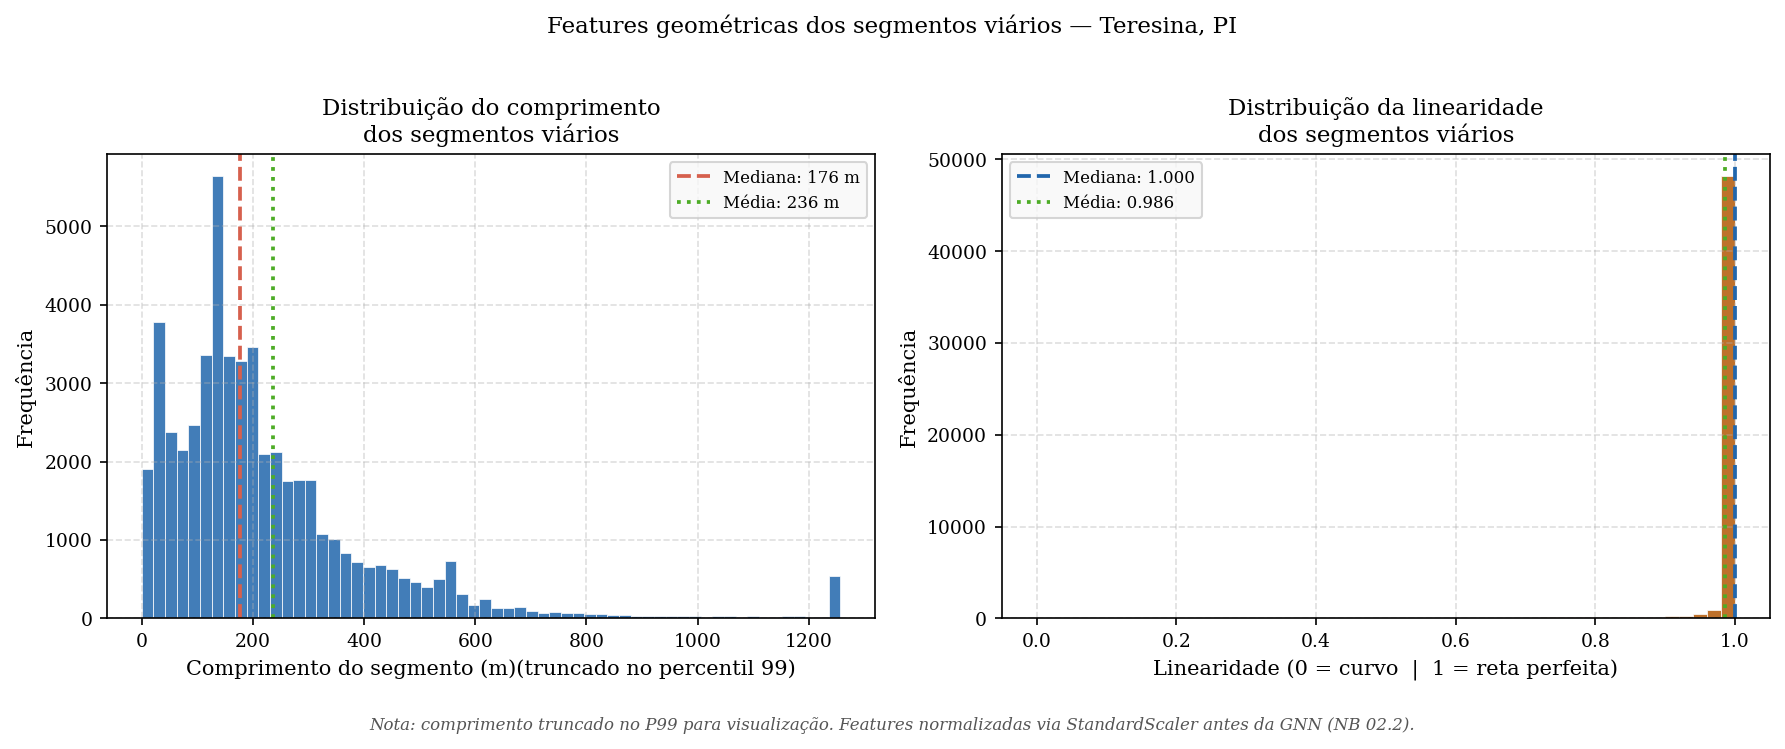

✅ Fig. 4.6 salva.


In [31]:
# ── Fig. 4.4 — Histogramas de comprimento e linearidade ──────────────────────
# Fundamentam a escolha de features para a GNN e caracterizam a malha para
# a seção de Metodologia da dissertação.

length_clip = road_process_barriers['length'].clip(upper=road_process_barriers['length'].quantile(0.99))
lin_data    = road_process_barriers['linearity']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Histograma de comprimento ---
ax1.hist(length_clip, bins=60, color='#2166AC', edgecolor='white',
         linewidth=0.4, alpha=0.85)
ax1.axvline(road_process_barriers['length'].median(), color='#D6604D', linewidth=1.8,
            linestyle='--', label=f'Mediana: {road_process_barriers["length"].median():.0f} m')
ax1.axvline(road_process_barriers['length'].mean(), color='#4DAC26', linewidth=1.8,
            linestyle=':', label=f'Média: {road_process_barriers["length"].mean():.0f} m')
ax1.set_xlabel('Comprimento do segmento (m)(truncado no percentil 99)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do comprimento\ndos segmentos viários')
ax1.legend(fontsize=8)
ax1.set_facecolor('white')

# --- Histograma de linearidade ---
ax2.hist(lin_data, bins=50, color='#B35806', edgecolor='white',
         linewidth=0.4, alpha=0.85)
ax2.axvline(lin_data.median(), color='#2166AC', linewidth=1.8,
            linestyle='--', label=f'Mediana: {lin_data.median():.3f}')
ax2.axvline(lin_data.mean(), color='#4DAC26', linewidth=1.8,
            linestyle=':', label=f'Média: {lin_data.mean():.3f}')
ax2.set_xlabel('Linearidade (0 = curvo  |  1 = reta perfeita)')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição da linearidade\ndos segmentos viários')
ax2.legend(fontsize=8)
ax2.set_facecolor('white')

# Nota metodológica
fig.text(0.5, -0.04,
    'Nota: comprimento truncado no P99 para visualização. '
    'Features normalizadas via StandardScaler antes da GNN (NB 02.2).',
    ha='center', fontsize=8, color='#555555', style='italic')

fig.suptitle('Features geométricas dos segmentos viários — Teresina, PI',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_6_features_geometricas.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.6 salva.')


In [32]:
road_process_barriers.head(10)

,id,names,subtype,class,subclass,subclass_rules,connectors,rail_flags,road_surface,road_flags,...,split_from,split_to,length,barrier_geometry,nomes_vias,surface_clean,velocidade_max,surf_group,linearity,classe_original
0,6f2590c9-8634-4557-87d4-7af0ef480c69,None,road,primary,None,None,[{'connector_id': '6deac8b8-2f44-49e0-a725-229...,None,"[{'value': 'paved', 'between': None}]",None,...,NaN,NaN,99.537305,"LINESTRING (-10065983.879 -1534877.712, -10065...",None,paved,NaN,Pavimentada,1.000000,primary
1,3126b0c8-ba5c-4998-9a0b-5a6475d6861a,"{'primary': 'Avenida Maranhão', 'common': None...",road,secondary,None,None,[{'connector_id': '9fe47c84-e28a-4716-b5c5-f23...,None,"[{'value': 'paved', 'between': None}]",None,...,NaN,NaN,510.850374,"LINESTRING (-10073254.085 -1508361.032, -10072...",Avenida Maranhão,paved,60.0,Pavimentada,1.000000,secondary
2,895a0223-bbd3-40c3-ba5c-fb7076c8fce1,None,road,residential,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,None,None,...,NaN,NaN,154.947600,"LINESTRING (-10065970.52 -1534779.076, -100658...",None,unknown,NaN,Desconhecida,1.000000,residential
3,1b21f057-464d-4e85-b650-d595c9cfa0af,None,road,primary,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,"[{'value': 'paved', 'between': None}]",None,...,NaN,NaN,898.876803,"LINESTRING (-10065966.023 -1534745.76, -100659...",None,paved,NaN,Pavimentada,0.999966,primary
4,29090412-2046-4011-8221-ffd287b0d00b,"{'primary': 'Rua Quatro Parque Saci', 'common'...",road,residential,None,None,[{'connector_id': '0ff8607d-8bb2-434e-aa64-d49...,None,None,None,...,NaN,NaN,199.085768,"LINESTRING (-10070965.715 -1510736.253, -10070...",Rua Quatro Parque Saci,unknown,NaN,Desconhecida,0.874458,residential
5,cb682c82-1a5e-476a-af63-858763615409,"{'primary': 'Rua Atlantida', 'common': None, '...",road,residential,None,None,[{'connector_id': '9ec5159b-640c-44a1-8435-920...,None,None,None,...,NaN,NaN,264.538239,"LINESTRING (-10071117.176 -1510240.074, -10071...",Rua Atlantida,unknown,NaN,Desconhecida,1.000000,residential
6,b1117c8b-b2a4-4616-aa23-a25a256ef4b6,None,road,residential,None,None,[{'connector_id': '1957f5dd-e1ef-4be4-b3a5-198...,None,None,None,...,NaN,NaN,156.066074,"LINESTRING (-10071069.301 -1510089.845, -10071...",None,unknown,NaN,Desconhecida,0.953463,residential
7,e88332fc-5fde-47ee-930b-0a472c9de46a,None,road,residential,None,None,[{'connector_id': '87dc0d57-cc57-4d5d-8cc7-b18...,None,None,None,...,NaN,NaN,666.745722,"LINESTRING (-10065966.023 -1534745.76, -100659...",None,unknown,NaN,Desconhecida,0.814589,residential
8,685401d6-584c-4818-a660-a74b4fc719dd,None,road,primary,None,None,[{'connector_id': '98235ecd-7ce6-4853-8732-a89...,None,"[{'value': 'paved', 'between': None}]",None,...,NaN,NaN,33.617320,"LINESTRING (-10065970.52 -1534779.076, -100659...",None,paved,NaN,Pavimentada,1.000000,primary
9,71c4b530-66f4-42b5-9bbe-1b1f3de68e55,"{'primary': 'Rua Um', 'common': None, 'rules':...",road,residential,None,None,[{'connector_id': '9a58069b-a05b-4278-a562-837...,None,"[{'value': 'unpaved', 'between': None}]",None,...,NaN,NaN,1516.892917,"LINESTRING (-10072505.353 -1509260.269, -10072...",Rua Um,unpaved,NaN,Não pavimentada,0.911256,residential


In [33]:
# Converte a coluna extra de Objeto Geométrico para Texto (WKT)
road_process_barriers['barriers_geometry_wkt'] = road_process_barriers['barrier_geometry'].to_wkt()
# road_process_barriers.drop(columns=['barrier_geometry'], inplace=True)

In [35]:
road_process_barriers.to_parquet(PROCESSED_PATH / "zonaUrbanaReal_3km_roadBarriers.parquet")

In [ ]:
# Agora o GeoPandas tem apenas UMA coluna geométrica verdadeira, e salva normalmente
road_process_barriers.to_file(PROCESSED_PATH / 'zonaUrbanaReal_3km_roadBarriers.geojson', driver="GeoJSON", )